In [1]:

import pandas as pd
from statsmodels.stats.multitest import multipletests
from Bio import SeqIO
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap
from matplotlib.colors import to_rgb
import matplotlib.gridspec as gridspec
from scipy.stats import mannwhitneyu

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib_venn import venn2
from matplotlib.colors import LinearSegmentedColormap


import os
plt.style.use('tableau-colorblind10')
# plt.rcParams.update({'font.family':'Arial'})
plt.rcParams.update({'font.size': 12, 'font.family':'Arial'})


In [2]:
base_dir = '/Users/cdubin/VMGC_cervical_dysplasia_paper/code/'

In [3]:
sample_metadata = pd.read_csv(f'{base_dir}/cervical_dysplasia/microSLAM/l_crispatus_inputs/VMGC_metadata.csv', index_col=0)
sample_metadata = sample_metadata[sample_metadata['num_reads'] > 250000]
sample_list = sample_metadata.index.tolist()
len(sample_list)

352

In [4]:
sample_metadata['Group_HC_dysplasia'].value_counts()

Group_HC_dysplasia
dysplasia    177
HC           175
Name: count, dtype: int64

In [5]:
species_order = ['Lactobacillus crispatus',
                                'Lactobacillus iners',
                                'Lactobacillus jensenii',
                                'Lactobacillus gasseri',
                                'Bifidobacterium vaginale',
                                'Fannyhessea vaginae']

In [6]:
species = pd.read_csv(f'{base_dir}/compare_VMGC_GTDB/select_species_for_analysis/shared_species_for_analysis.csv')
species = species.set_index('species').loc[species_order].reset_index()
species

,species,species_id_GTDB,num_samples_GTDB,species_id_VMGC,num_samples_VMGC
0,Lactobacillus crispatus,100122,135,988598,135
1,Lactobacillus iners,100505,120,240891,121
2,Lactobacillus jensenii,100515,35,571325,35
3,Lactobacillus gasseri,100460,20,611554,20
4,Bifidobacterium vaginale,100323,78,783244,78
5,Fannyhessea vaginae,103895,65,619501,43


In [7]:
sp_id_to_name = species.set_index('species_id_VMGC')['species'].to_dict()
sp_name_to_id = species.set_index('species')['species_id_VMGC'].to_dict()
sp_vmgc_to_gtdb = species.set_index('species_id_VMGC')['species_id_GTDB'].to_dict()

sp_list = species['species_id_VMGC'].tolist()

In [8]:
pangenome_counts = pd.read_csv('../../pangenome_counts.csv', index_col=0)

pangenome_counts = pangenome_counts[pangenome_counts['VMGC_species_code'].isin(sp_list)]
pangenome_counts = pangenome_counts[pangenome_counts['cluster_level'] == 90]
pangenome_counts

,species_name,cluster_level,VMGC_pangenome_size,GTDB_pangenome_size,VMGC_species_code,MIDAS_species_code,VMGC_num_genomes,MIDAS_num_genomes,larger_pangenome,pangenome_size_diff
3,Lactobacillus iners,90,6602,1966,240891,100505,1876,31,VMGC,-4636
9,Fannyhessea vaginae,90,6256,1448,619501,103895,786,5,VMGC,-4808
15,Bifidobacterium vaginale,90,6618,2467,783244,100323,700,49,VMGC,-4151
21,Lactobacillus crispatus,90,10704,8817,988598,100122,856,128,VMGC,-1887
57,Lactobacillus jensenii,90,3353,2113,571325,100515,327,29,VMGC,-1240
105,Lactobacillus gasseri,90,5083,3409,611554,100460,202,33,VMGC,-1674


In [9]:
100*((pangenome_counts['VMGC_pangenome_size']/pangenome_counts['GTDB_pangenome_size']) - 1)

3      235.808749
9      332.044199
15     168.261046
21      21.401837
57      58.684335
105     49.105309
dtype: float64

In [10]:
genes_summary = pd.read_csv(f'{base_dir}/cervical_dysplasia/MIDAS3/combined_ref/results_C90/merge/genes/genes_summary.tsv', sep='\t')

for sp in sp_list:
    pres_abs_file =f'{base_dir}/cervical_dysplasia/MIDAS3/combined_ref/results_C90/merge/genes/{sp}/{sp}.genes_presabs.tsv.lz4'
    if os.path.exists(pres_abs_file.replace('.lz4','')):
        continue
    !lz4 -d {pres_abs_file}

In [11]:
sp_pres_abs = {}
sp_centroids = {}
sp_prop_detected = {}

for sp in sp_list:
    pres_abs = pd.read_csv(f'/Users/cdubin/Library/CloudStorage/Box-Box/cervical_dysplasia/MIDAS3/combined_ref/results_C90_local/merge/genes/{sp}/{sp}.genes_presabs.tsv', sep='\t', index_col=0)
    pres_abs = pres_abs[[i for i in sample_list if i in pres_abs.columns]]
    sp_genes_summary = genes_summary[genes_summary['species_id'] == sp]
    sp_genes_summary = sp_genes_summary[sp_genes_summary['mean_depth'] >= 5 ]
    
    pres_abs = pres_abs[[i for i in sp_genes_summary['sample_name'].values if i in pres_abs.columns]]
    sp_pres_abs[sp] = pres_abs

    sample_list += pres_abs.columns.tolist()

    centroid_classification = pd.read_csv(f'/Users/cdubin/Library/CloudStorage/Box-Box/cervical_dysplasia/combined_db/combined_db_analysis/centroid_classification/{sp}_C90_classified.csv')

    num_samples_detected_per_gene = pres_abs.sum(axis=1)
    prop_samples_detected_per_gene = num_samples_detected_per_gene/pres_abs.shape[1]

    sp_prop_detected[sp] = prop_samples_detected_per_gene

    prop_samples_detected_per_gene_min_1 = prop_samples_detected_per_gene[prop_samples_detected_per_gene > 0]
    centroid_classification['detected'] = centroid_classification['centroid_90'].isin(prop_samples_detected_per_gene_min_1.index).astype(int)

    sp_centroids[sp] = centroid_classification


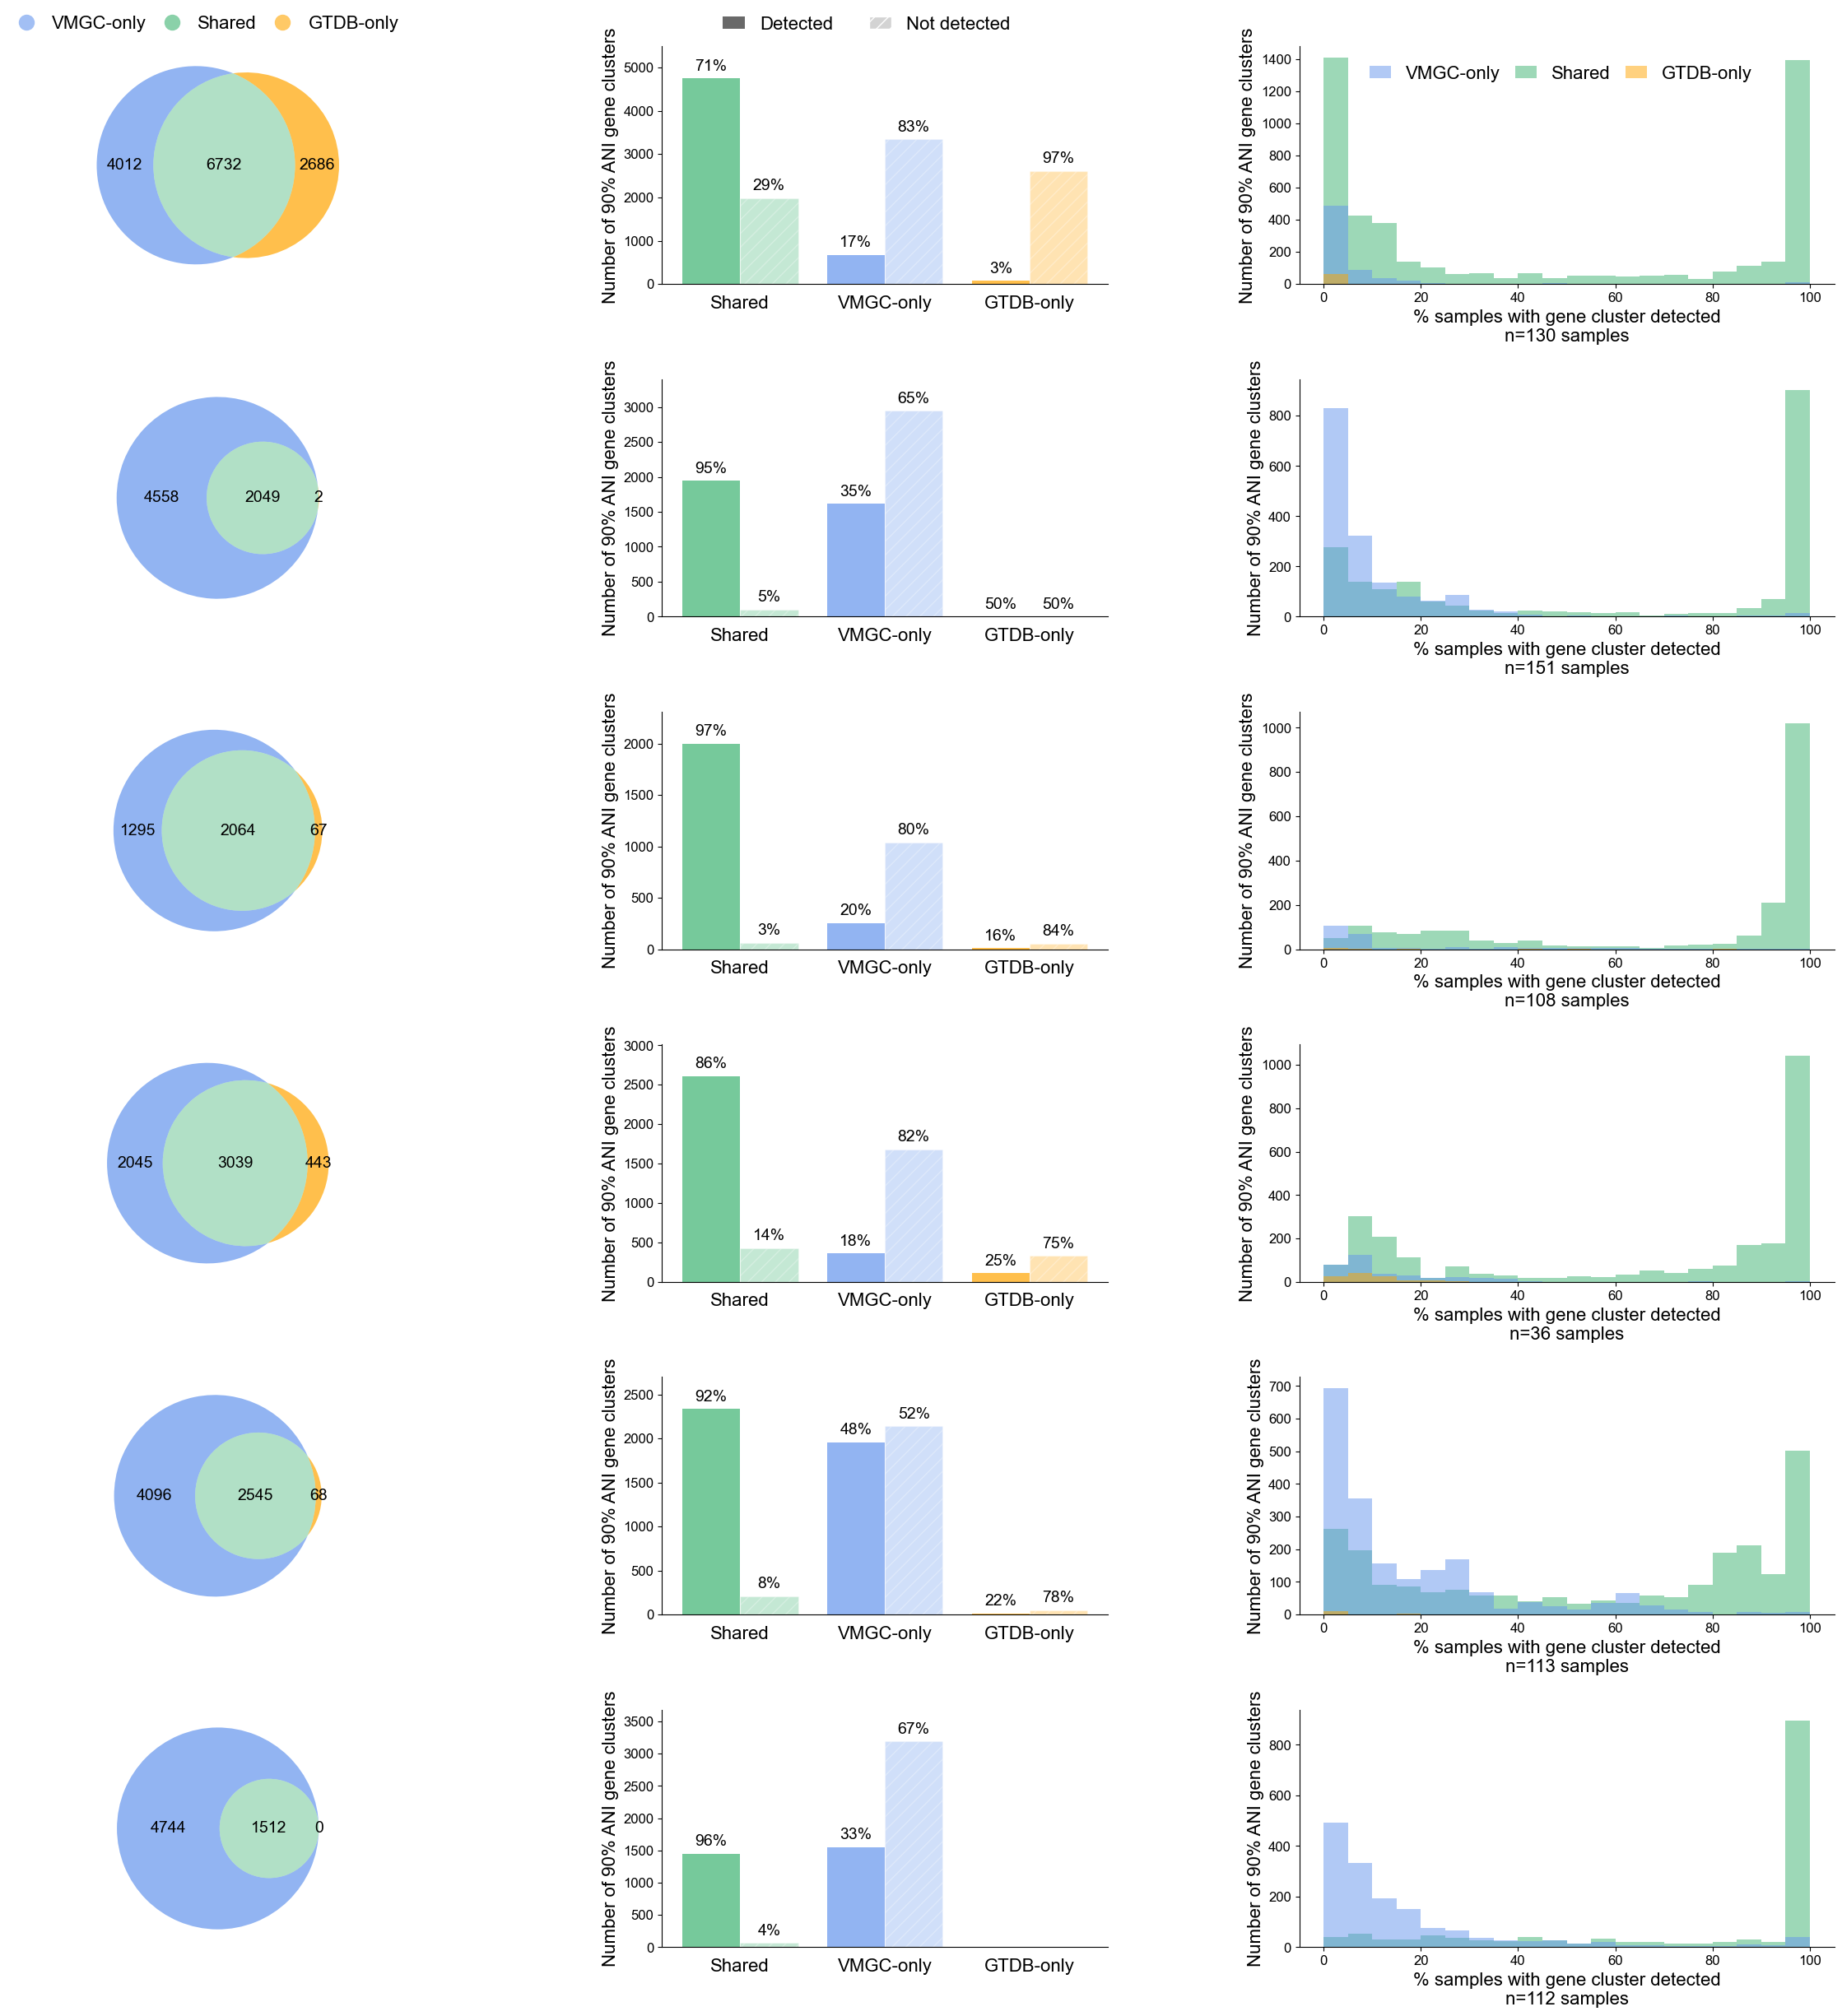

In [12]:


# Layout constants
n_rows = 6
n_cols = 5
figsize = (30, 30) 

fig, axs = plt.subplots(n_rows, n_cols, figsize=figsize, width_ratios=[2,0.05,1.5,0.2,1.8])
axs = axs.reshape(n_rows, n_cols)

colors = ['mediumseagreen', 'cornflowerblue', 'orange']

groups = ['Mixed','VMGC', 'GTDB']
group_labels = ['Mixed', 'VMGC', 'GTDB',]

# ==== ROW 1: VENN DIAGRAMS ====
for i, v in enumerate(sp_list):
    ax = axs[i, 0]
    counts = sp_centroids[v].set_index('centroid_90')['classification'].value_counts() 
    if 'GTDB' not in counts.index:
        counts['GTDB'] = 0        
    s = (counts.loc['VMGC'], counts.loc['GTDB'], counts.loc['Mixed'])
    species_name = species.set_index('species_id_VMGC').loc[v]['species']

    vd = venn2(
        subsets=s,
        set_labels=None,
        ax=ax,
        set_colors=('cornflowerblue', 'orange'),
        alpha=0.7, 
    )

    for label in vd.subset_labels:
        if label:
            label.set_fontsize(14)

    vd.get_patch_by_id('11').set_color('mediumseagreen')
    vd.get_patch_by_id('11').set_edgecolor('none')
    vd.get_patch_by_id('11').set_alpha(0.4)

    # ax.set_title(f"{species_name}", fontsize=20, style='italic')

# Custom Venn Legend
venn_labels = ['VMGC-only', 'Shared', 'GTDB-only']
venn_colors = ['cornflowerblue', 'mediumseagreen', 'orange']
venn_handles = [
    Line2D([0], [0], marker='o', color='none', label=label,
           markerfacecolor=color, markeredgewidth=0, markersize=14, alpha=0.6)
    for label, color in zip(venn_labels, venn_colors)
]
axs[0, 0].legend(handles=venn_handles,  ncols=3,
                 columnspacing=0.8, frameon=False, fontsize=16,
                 handlelength=1.2, bbox_to_anchor=(1.2,1.2))




# ==== ROW 2: GENE DETECTION BARS ====
# Initialize counts with 0 for all groups

for i, sp in enumerate(sp_list):
    ax_bar = axs[i, 2]

    pres_abs = sp_pres_abs[sp]
    centroid_classification = sp_centroids[sp]
    prop_detected = sp_prop_detected[sp]
    prop_samples_detected_per_gene_min_1 = prop_detected[prop_detected > 0]
    centroids_grouped_by_class = centroid_classification.groupby('classification')['centroid_90'].apply(list).to_dict()

    detected_counts_dict = {g: 0 for g in group_labels}
    not_detected_counts_dict = {g: 0 for g in group_labels}
    color_dict = dict(zip(groups, colors))

    for group in group_labels:
        if group not in centroids_grouped_by_class:
            continue
        group_centroids = centroids_grouped_by_class[group]
        group_df = centroid_classification[centroid_classification['centroid_90'].isin(group_centroids)]
        n_detected = group_df[group_df['detected'] == 1].shape[0]
        n_not_detected = group_df.shape[0] - n_detected
        detected_counts_dict[group] = n_detected
        not_detected_counts_dict[group] = n_not_detected

    detected_counts = [detected_counts_dict[g] for g in group_labels]
    not_detected_counts = [not_detected_counts_dict[g] for g in group_labels]
    group_colors = [color_dict[g] for g in group_labels]


    bar_width = 0.4
    x = np.arange(len(group_labels))
    ax_bar.bar(x - bar_width/2, detected_counts, width=bar_width, color=group_colors, label='Detected', alpha=0.7)
    ax_bar.bar(x + bar_width/2, not_detected_counts, width=bar_width, color=group_colors, label='Not Detected', edgecolor='white', hatch='//', alpha=0.3)

    # X-axis labels under each group of bars

    to_append = ['','-only','-only']
    for _, xi in enumerate(x):
        # ax_bar.text(xi - bar_width/2 - 0.05, -ax_bar.get_ylim()[1]*0.07, 'Detected', ha='center', va='top', fontsize=10)
        # ax_bar.text(xi + bar_width/2 + 0.05 , -ax_bar.get_ylim()[1]*0.07, 'Not\nDetected', ha='center', va='top', fontsize=10)
        ax_bar.text(xi , -ax_bar.get_ylim()[1]*0.05, group_labels[_].replace('Mixed', 'Shared')+to_append[_], ha='center', va='top', fontsize=16)


    ax_bar.set_xticks([])
    # ax_bar.set_xticklabels(group_labels,)
    ax_bar.set_ylim(0,ax_bar.get_ylim()[1]*1.1)  

    # ──‑‑‑‑‑ Add % labels that sum to 100 for each Detected / Not‑Detected pair ‑‑‑‑‑──
    for idx, (det, notdet) in enumerate(zip(detected_counts, not_detected_counts)):
        total = det + notdet
        if total == 0:        # skip empty groups
            continue
        pct_det = int(round(det / total * 100))
        pct_not = 100 - pct_det

        # Slight vertical offset so text clears the bar top
        y_offset = ax_bar.get_ylim()[1] * 0.02
        ax_bar.text(x[idx] - bar_width/2, det + y_offset,  f"{pct_det}%",  ha="center", va="bottom", fontsize=14)
        ax_bar.text(x[idx] + bar_width/2, notdet + y_offset, f"{pct_not}%", ha="center", va="bottom", fontsize=14)

    ax_bar.spines['top'].set_visible(False)
    ax_bar.spines['right'].set_visible(False)

    # if i == 0:
    ax_bar.set_ylabel('Number of 90% ANI gene clusters', fontsize=16)

# Detection Legend
det_legend = [
    Patch(facecolor='dimgray', label='Detected'),
    Patch(facecolor='lightgray', edgecolor='white', hatch='//', label='Not detected'),

]
axs[0, 2].legend(handles=det_legend,fontsize=16, frameon=False,
                 bbox_to_anchor=(0.1,.99),ncols=2, handlelength=1.2)

# ==== ROW 3: FREQUENCY SPECTRUM ====
bins = np.arange(0, 101, 5) / 100

for i, sp in enumerate(sp_list):
    ax = axs[i, 4]
    pres_abs = sp_pres_abs[sp]
    centroid_classification = sp_centroids[sp]
    prop_detected = sp_prop_detected[sp]
    prop_samples_detected_per_gene_min_1 = prop_detected[prop_detected > 0]
    centroids_grouped_by_class = centroid_classification.groupby('classification')['centroid_90'].apply(list).to_dict()

    for j, group, color in zip(range(4), groups, colors):
        if group == 'All':
            continue
        if group not in centroids_grouped_by_class:
            continue

        centroid_group_list = [i for i in centroids_grouped_by_class[group] if i in prop_samples_detected_per_gene_min_1.index]
        sns.histplot(prop_samples_detected_per_gene_min_1.loc[centroid_group_list], 
                     ax=ax, color=color, label=group, bins=bins,
                     alpha=0.5, edgecolor='none')

    num_samples = sp_pres_abs[sp].shape[1]


    ax.set_xlabel(f'% samples with gene cluster detected\nn={num_samples} samples', fontsize=16)
    ax.set_ylabel('Number of 90% ANI gene clusters', fontsize=16)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    xticks = np.arange(0,101,20)
    ax.set_xticks(xticks/100, labels=xticks)

# Frequency Legend
freq_legend = [
    Patch(facecolor='cornflowerblue', label='VMGC-only', alpha=0.5),
    Patch(facecolor='mediumseagreen', label='Shared', alpha=0.5),
    Patch(facecolor='orange', label='GTDB-only', alpha=0.5),
]

axs[0, 4].legend(handles=freq_legend,  ncols=3,
                 columnspacing=0.8, frameon=False, fontsize=16,
                 handlelength=1.2,  bbox_to_anchor=(0.1,.99))

for row in range(6):  # Iterate through columns in the specified row
    axs[row, 1].set_visible(False)
    axs[row, 3].set_visible(False)


# plt.tight_layout(rect=[0, 0, 1, 0.95])
fig_dir = '/Users/cdubin/VMGC_cervical_dysplasia_paper/figures/'
plt.subplots_adjust(hspace=0.4,) # Increase horizontal and vertical spacing
plt.savefig(f'{fig_dir}/figure_3.png', dpi=900, bbox_inches="tight")

plt.show()


In [13]:


for i, sp in enumerate(sp_list):

    pres_abs = sp_pres_abs[sp]
    centroid_classification = sp_centroids[sp]
    prop_detected = sp_prop_detected[sp]
    prop_samples_detected_per_gene_min_1 = prop_detected[prop_detected>0]
    centroids_grouped_by_class = centroid_classification.groupby('classification')['centroid_90'].apply(list).to_dict()

    if 'GTDB' not in centroids_grouped_by_class:
        continue

    vmgc_freqs = [prop_detected[c]  for c in centroids_grouped_by_class['VMGC'] if c in prop_samples_detected_per_gene_min_1 ]
    gtdb_freqs = [prop_detected[c] for c in centroids_grouped_by_class['GTDB']  if c in prop_samples_detected_per_gene_min_1]

    if len(gtdb_freqs) < 5 or len(vmgc_freqs) < 5:
        print(f'not enough genes for {sp_id_to_name[sp]}')
        print(

        )
        continue

    
    print(sp_id_to_name[sp])
    print(len(vmgc_freqs), len(gtdb_freqs))
    print(mannwhitneyu(vmgc_freqs,gtdb_freqs, alternative='two-sided'))

    print()

Lactobacillus crispatus
674 74
MannwhitneyuResult(statistic=np.float64(32621.5), pvalue=np.float64(6.711674175737865e-06))

not enough genes for Lactobacillus iners

Lactobacillus jensenii
256 11
MannwhitneyuResult(statistic=np.float64(1628.5), pvalue=np.float64(0.3781557577661626))

Lactobacillus gasseri
361 112
MannwhitneyuResult(statistic=np.float64(22221.0), pvalue=np.float64(0.10805356611056921))

Bifidobacterium vaginale
1957 15
MannwhitneyuResult(statistic=np.float64(21332.5), pvalue=np.float64(0.002415972799623091))

